In [19]:
import numpy as np
from scipy.signal import chirp, correlate

import numpy as np
def process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps,resampling_factor=1):
    ref_samples = np.fromfile(fileName_ref, np.complex64)
    rx_samples = np.fromfile(fileName_rx, np.complex64) 
    print("ref_samples size: ", ref_samples.size)
    print("rx_samples size: ", rx_samples.size)

    #normalise samples
    # ref_samples = low_pass_filter(500e3,5e6,4,ref_samples)
    # rx_samples = low_pass_filter(500e3,5e6,4,rx_samples)
    # ref_samples = normaliseSignals(ref_samples,burst_len,num_steps)
    # rx_samples = normaliseSignals(rx_samples,burst_len,num_steps)

    #reshape samples into busrt
    rx_samples_reshaped = rx_samples.reshape([num_steps,-1])
    #rx_samples_reshaped = signal.resample(rx_samples_reshaped,int(burst_len*resampling_factor),axis=1)
    #rx_samples_reshaped = signal.resample_poly(rx_samples_reshaped,resampling_factor,1,axis=1)
    ref_samples_reshaped = ref_samples.reshape([num_steps,-1])
    #ref_samples_reshaped = signal.resample(ref_samples_reshaped,int(burst_len*resampling_factor),axis=1)
    #ref_samples_reshaped = signal.resample_poly(ref_samples_reshaped,resampling_factor,1,axis=1)

    #drop noisy samples
    # rx_samples_reshaped = rx_samples_reshaped[:,100:100+int(burst_len/2)]
    # ref_samples_reshaped = ref_samples_reshaped[:,100:100+int(burst_len/2)]

    return rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples

Generated A-scan. Target peak found at range bin: 50


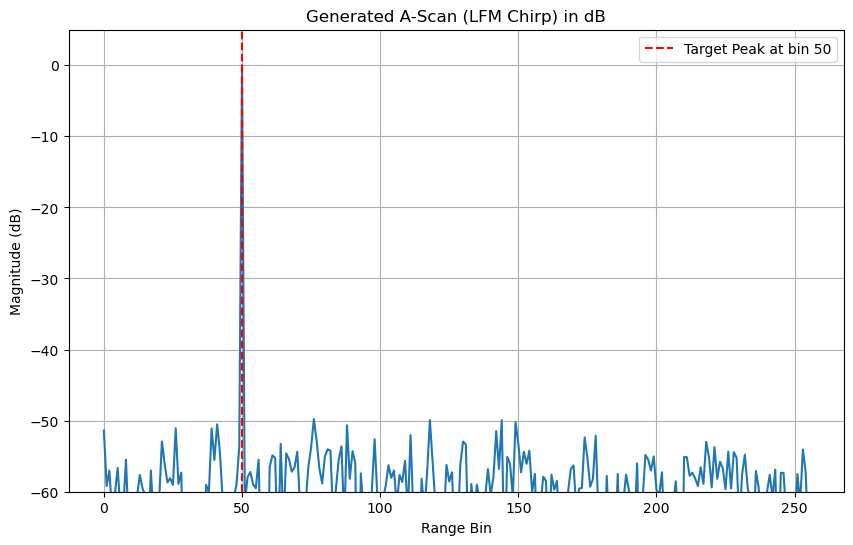

In [20]:


def generate_ascan_from_lfm(
    echo_signals: np.ndarray,
    reference_signals: np.ndarray,
    num_steps: int,
    step_length: int,
    chirp_bandwidth: float,
    sampling_rate_hz: float
) -> np.ndarray:
    """
    Generates an A-scan range profile for an LFM-chirp SFCW radar.

    This function performs matched filtering, phase coherence compensation, and
    then applies an IFFT to synthesize the time-domain range profile.

    Args:
        echo_signals: A 1D numpy array containing the concatenated raw IQ
                      samples from the target echo channel.
        reference_signals: A 1D numpy array containing the concatenated raw IQ
                           samples from the reference (loopback) channel.
        num_steps: The total number of frequency steps in the sweep.
        step_length: The number of IQ samples recorded for each frequency step.
        chirp_bandwidth: The bandwidth of the LFM chirp sub-pulse (in Hz).
        sampling_rate_hz: The sampling rate of the SDR's ADC (in Hz).

    Returns:
        A 1D numpy array representing the complex A-scan (range profile).
    """
    # Reshape the 1D arrays into 2D arrays of (num_steps, step_length)
    echo_matrix = echo_signals.reshape(num_steps, step_length)
    ref_matrix = reference_signals.reshape(num_steps, step_length)

    # --- Step 1: Generate the local matched filter (reference chirp) ---
    pulse_duration = step_length / sampling_rate_hz
    t = np.linspace(0, pulse_duration, step_length, endpoint=False)
    local_chirp = chirp(t, f0=-chirp_bandwidth/2, f1=chirp_bandwidth/2, t1=pulse_duration, method='linear')
    
    # --- Step 2: Extract Complex Channel Response via Matched Filtering ---
    echo_response = np.zeros(num_steps, dtype=np.complex64)
    ref_response = np.zeros(num_steps, dtype=np.complex64)

    for i in range(num_steps):
        # Correlate echo with local chirp to find the compressed peak
        correlation_echo = correlate(echo_matrix[i, :], local_chirp, mode='same')
        peak_index_echo = np.argmax(np.abs(correlation_echo))
        echo_response[i] = correlation_echo[peak_index_echo]

        # Correlate reference with local chirp to find the compressed peak
        correlation_ref = correlate(ref_matrix[i, :], local_chirp, mode='same')
        peak_index_ref = np.argmax(np.abs(correlation_ref))
        ref_response[i] = correlation_ref[peak_index_ref]

    # --- Step 3: Perform Phase Coherence Compensation ---
    epsilon = 1e-12
    calibrated_frequency_response = echo_response / (ref_response + epsilon)

    # --- Step 4: Synthesize the A-scan (Range Profile) ---
    #a_scan = np.fft.ifftshift(np.fft.ifft(calibrated_frequency_response))
    a_scan = np.fft.ifft(calibrated_frequency_response)

    return a_scan

In [29]:
SAMPLING_RATE = 10e6    # 5 MHz
CHIRP_BANDWIDTH = 1e6  # 1 MHz
burst_len = 1024+64
num_steps = 128
supposed_size = burst_len*num_steps
dir = '/home/hui/bladerf_sfcw_radar/gui/'
prefix = 'loop_back_chirp'
i=0
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
rx_samples_reshaped, ref_samples_reshaped, rx_samples, ref_samples = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps)

ref_samples size:  139264
rx_samples size:  139264


Generated A-scan. Target peak found at range bin: 4


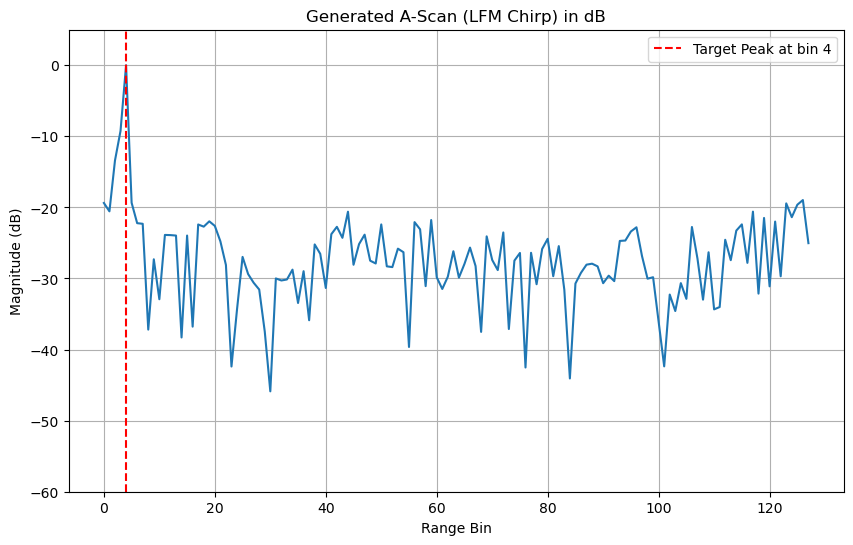

In [30]:
    # --- Generate the A-scan using the function ---
    ascan_profile = generate_ascan_from_lfm(
        echo_signals=rx_samples,
        reference_signals=ref_samples,
        num_steps=num_steps,
        step_length=burst_len,
        chirp_bandwidth=CHIRP_BANDWIDTH,
        sampling_rate_hz=SAMPLING_RATE
    )

    # --- Plot the result in dB ---
    try:
        import matplotlib.pyplot as plt
        
        magnitude = np.abs(ascan_profile)
        normalized_magnitude = magnitude / np.max(magnitude)
        ascan_db = 20 * np.log10(normalized_magnitude + 1e-9)
        
        plt.figure(figsize=(10, 6))
        plt.plot(ascan_db)
        plt.title("Generated A-Scan (LFM Chirp) in dB")
        plt.xlabel("Range Bin")
        plt.ylabel("Magnitude (dB)")
        plt.grid(True)
        plt.ylim(-60, 5)
        
        peak_location = np.argmax(ascan_db)
        plt.axvline(x=peak_location, color='r', linestyle='--', label=f'Target Peak at bin {peak_location}')
        plt.legend()
        print(f"Generated A-scan. Target peak found at range bin: {peak_location}")
        
        plt.show()

    except ImportError:
        print("Matplotlib not found. Please install it to see the plot (`pip install matplotlib`).")
        print(f"Generated A-scan. Target peak found at range bin: {np.argmax(np.abs(ascan_profile))}")


In [31]:
def calculate_snr(a_scan: np.ndarray, exclusion_width: int = 5) -> float:
    """
    Calculates the Signal-to-Noise Ratio (SNR) of a radar A-scan.

    The SNR is calculated as the ratio of the peak signal power to the
    average noise power in the profile.

    Args:
        a_scan: A 1D numpy array containing the complex or real A-scan data.
        exclusion_width: The number of samples around the peak to exclude
                         from the noise calculation. Must be an odd number.

    Returns:
        The calculated SNR in decibels (dB).
    """
    if exclusion_width % 2 == 0:
        raise ValueError("Exclusion width must be an odd number.")

    # --- 1. Calculate Magnitudes and Find Peak Signal Power ---
    # Use np.abs() to handle both real and complex inputs
    magnitudes = np.abs(a_scan)
    signal_peak_magnitude = np.max(magnitudes)
    signal_power = signal_peak_magnitude**2
    peak_index = np.argmax(magnitudes)

    # --- 2. Identify and Calculate Average Noise Power ---
    # Create a copy of the magnitudes to use for noise calculation
    noise_magnitudes = magnitudes.copy()
    
    # Define the exclusion zone around the peak
    half_width = exclusion_width // 2
    start_exclusion = max(0, peak_index - half_width)
    end_exclusion = min(len(a_scan), peak_index + half_width + 1)
    
    # Set the values in the exclusion zone to NaN (Not a Number)
    noise_magnitudes[start_exclusion:end_exclusion] = np.nan
    
    # Calculate the average noise power using nanmean, which ignores NaNs
    average_noise_power = np.nanmean(noise_magnitudes**2)
    
    # --- 3. Calculate SNR in dB ---
    # Add a small epsilon to avoid log10(0) if noise power is zero
    epsilon = 1e-12
    snr_ratio = signal_power / (average_noise_power + epsilon)
    snr_db = 10 * np.log10(snr_ratio)

    return snr_db

In [32]:
calculate_snr(ascan_profile)

np.float32(25.706465)